In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
test_df=pd.read_csv("./test.csv")
train_df=pd.read_csv("./train.csv")

In [5]:
train_df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [6]:
test_df.columns

Index(['PassengerId', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch',
       'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [7]:
# preview data
train_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [10]:
train_df.set_index(train_df.PassengerId, inplace=True)
train_df.drop("PassengerId",axis=1,inplace=True)
train_df.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [11]:
test_df=pd.read_csv("./test.csv",index_col="PassengerId")
test_df.head()

,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,
892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [12]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 891 entries, 1 to 891
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Name      891 non-null    object 
 3   Sex       891 non-null    object 
 4   Age       714 non-null    float64
 5   SibSp     891 non-null    int64  
 6   Parch     891 non-null    int64  
 7   Ticket    891 non-null    object 
 8   Fare      891 non-null    float64
 9   Cabin     204 non-null    object 
 10  Embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 83.5+ KB


In [13]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 418 entries, 892 to 1309
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Pclass    418 non-null    int64  
 1   Name      418 non-null    object 
 2   Sex       418 non-null    object 
 3   Age       332 non-null    float64
 4   SibSp     418 non-null    int64  
 5   Parch     418 non-null    int64  
 6   Ticket    418 non-null    object 
 7   Fare      417 non-null    float64
 8   Cabin     91 non-null     object 
 9   Embarked  418 non-null    object 
dtypes: float64(2), int64(3), object(5)
memory usage: 35.9+ KB


In [14]:
train_df["Survived"]=train_df["Survived"].astype("category")

In [18]:
features=["Pclass","Sex","SibSp","Parch","Embarked"]
def convert_cat(df,features):
    for feature in features:
        df[feature]=df[feature].astype("category")
convert_cat(train_df,features)
convert_cat(test_df,features)

In [19]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 891 entries, 1 to 891
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   Survived  891 non-null    category
 1   Pclass    891 non-null    category
 2   Name      891 non-null    object  
 3   Sex       891 non-null    category
 4   Age       714 non-null    float64 
 5   SibSp     891 non-null    category
 6   Parch     891 non-null    category
 7   Ticket    891 non-null    object  
 8   Fare      891 non-null    float64 
 9   Cabin     204 non-null    object  
 10  Embarked  889 non-null    category
dtypes: category(6), float64(2), object(3)
memory usage: 48.2+ KB


### Distribution of Numerical

In [20]:
train_df.describe()

,Age,Fare
count,714.000000,891.000000
mean,29.699118,32.204208
std,14.526497,49.693429
min,0.420000,0.000000
25%,20.125000,7.910400
50%,28.000000,14.454200
75%,38.000000,31.000000
max,80.000000,512.329200


### Distribution of Categorical

In [21]:
train_df.describe(include=['category'])

,Survived,Pclass,Sex,SibSp,Parch,Embarked
count,891,891,891,891,891,889
unique,2,3,2,7,7,3
top,0,3,male,0,0,S
freq,549,491,577,608,678,644


## Explore Data Analysis

In [23]:
train_df["Survived"].value_counts(normalize=True).to_frame()

,proportion
Survived,
0,0.616162
1,0.383838


In [24]:
train_df["Sex"].value_counts().to_frame()

,count
Sex,
male,577
female,314


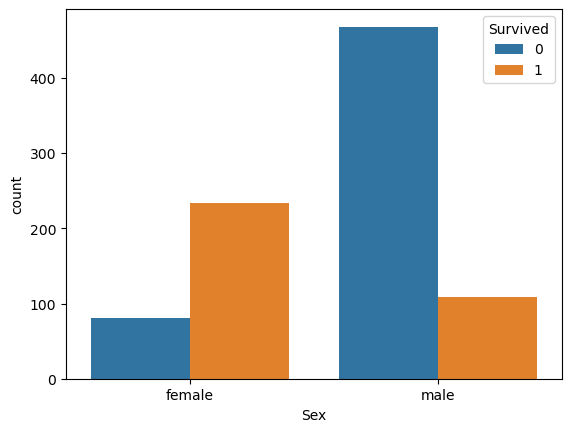

In [28]:
import seaborn as sns
sns.countplot(data=train_df,x='Sex',hue='Survived');

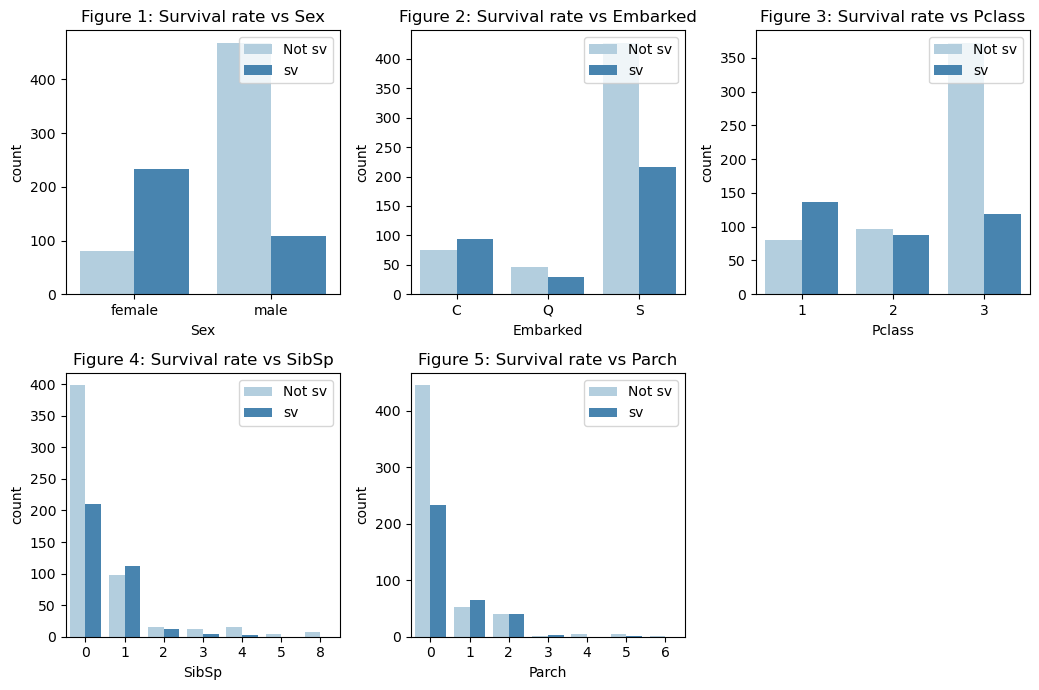

In [35]:
cols=['Sex','Embarked','Pclass','SibSp','Parch']
n_rows=2
n_cols=3
fig,ax=plt.subplots(n_rows,n_cols,figsize=(n_cols*3.5,n_rows*3.5))
for r in range(0,n_rows):
    for c in range(0,n_cols):
        i=r*n_cols+c #index to loop through list "cols"
        if i<len(cols):
            ax_i=ax[r,c]
            sns.countplot(data=train_df,x=cols[i],hue="Survived",palette="Blues",ax=ax_i)
            ax_i.set_title(f"Figure {i+1}: Survival rate vs {cols[i]}")
            ax_i.legend(title='',loc='upper right',labels=['Not sv', 'sv'])
ax.flat[-1].set_visible(False)
plt.tight_layout()

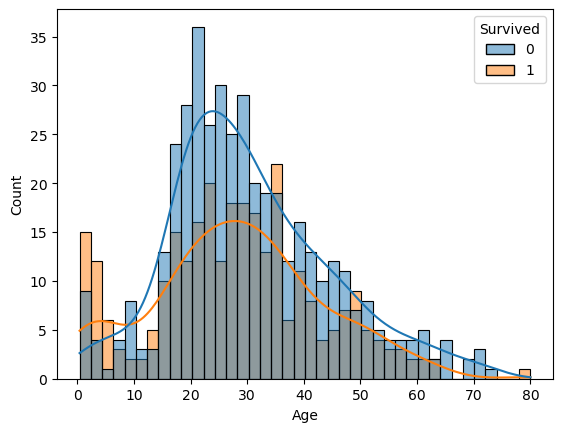

In [39]:
sns.histplot(data=train_df,x='Age',hue='Survived',bins=40,kde=True);

In [40]:
train_df["Fare"].describe()

count    891.000000
mean      32.204208
std       49.693429
min        0.000000
25%        7.910400
50%       14.454200
75%       31.000000
max      512.329200
Name: Fare, dtype: float64

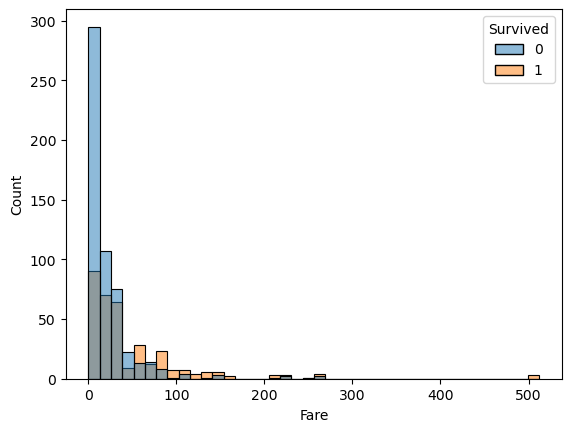

In [43]:
sns.histplot(data=train_df,x='Fare',hue='Survived',bins=40);

<Axes: xlabel='Fare', ylabel='count'>

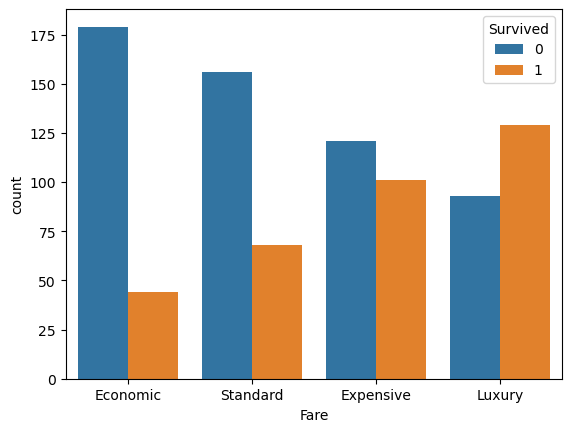

In [46]:
fare_categories=['Economic','Standard','Expensive','Luxury']
q_data=pd.qcut(train_df['Fare'],4,labels=fare_categories)
sns.countplot(x=q_data,hue=train_df['Survived'])

### Feature Engineering & Data Wrangling

In [47]:
train_df['Name']

PassengerId
1                                Braund, Mr. Owen Harris
2      Cumings, Mrs. John Bradley (Florence Briggs Th...
3                                 Heikkinen, Miss. Laina
4           Futrelle, Mrs. Jacques Heath (Lily May Peel)
5                               Allen, Mr. William Henry
                             ...                        
887                                Montvila, Rev. Juozas
888                         Graham, Miss. Margaret Edith
889             Johnston, Miss. Catherine Helen "Carrie"
890                                Behr, Mr. Karl Howell
891                                  Dooley, Mr. Patrick
Name: Name, Length: 891, dtype: object

In [54]:
import re
def extract_title(name):
    p=re.compile(r",([\w\s]+)\.")
    return p.search(name).groups(1)[0].strip()
train_df['Title']=train_df['Name'].apply(lambda name:extract_title(name))
train_df['Title'].value_counts()

Title
Mr              517
Miss            182
Mrs             125
Master           40
Dr                7
Rev               6
Mlle              2
Major             2
Col               2
the Countess      1
Capt              1
Ms                1
Sir               1
Lady              1
Mme               1
Don               1
Jonkheer          1
Name: count, dtype: int64

In [55]:
test_df['Title']=test_df['Name'].apply(lambda name:extract_title(name))
test_df['Title'].value_counts()

Title
Mr        240
Miss       78
Mrs        72
Master     21
Col         2
Rev         2
Ms          1
Dr          1
Dona        1
Name: count, dtype: int64

In [59]:
def group_title(title):
    if title in ['Mr','Mrs','Miss','Master']:
        return title
    elif title=="Ms":
        return "Miss"
    else:
        return "Others"

train_df['Title']= train_df['Title'].apply( lambda title:group_title(title))
test_df['Title']= test_df['Title'].apply( lambda title:group_title(title))


<Axes: xlabel='Title', ylabel='count'>

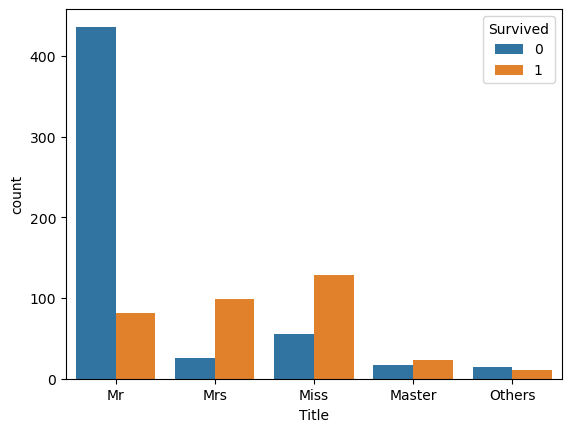

In [60]:
sns.countplot(data=train_df,x='Title',hue='Survived')

### Group SibSp and Parch

In [66]:
train_df['Family_size']=train_df['SibSp'].astype('int')+train_df['Parch'].astype('int')+1

In [68]:
test_df['Family_size']=test_df['SibSp'].astype('int')+test_df['Parch'].astype('int')+1

In [72]:
test_df['Family_Cat']=pd.cut(test_df['Family_size'],bins=[0,1,4,6,20],labels=['Solo','Small','Medium','Large'])
train_df['Family_Cat']=pd.cut(train_df['Family_size'],bins=[0,1,4,6,20],labels=['Solo','Small','Medium','Large'])

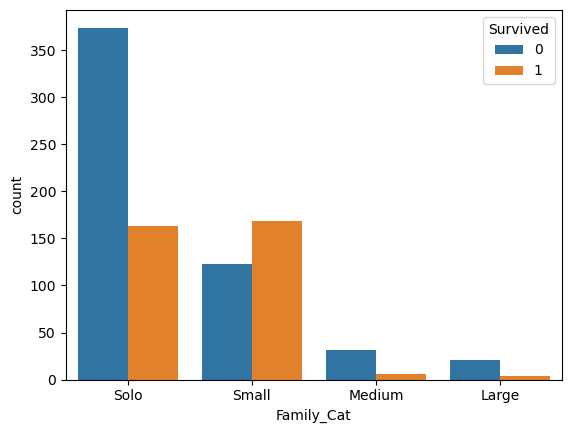

In [70]:
sns.countplot(data=train_df,x='Family_Cat',hue='Survived');

### Data Wrangling

In [71]:
num_features=['Age','Fare']
cat_features=['Sex','Pclass','Embarked','Title','Family_Cat']
feature_cols=num_features+cat_features
print(feature_cols)

['Age', 'Fare', 'Sex', 'Pclass', 'Embarked', 'Title', 'Family_Cat']


In [74]:
def display_missing(df,feature_cols):
    n_rows=df.shape[0]
    for col in feature_cols:
        missing_count=df[col].isnull().sum()
        if missing_count>0:
            print(f" {col} has {missing_count*100/n_rows:.2f}% missing values.")
display_missing(train_df,feature_cols)

display_missing(test_df,feature_cols)

 Age has 19.87% missing values.
 Embarked has 0.22% missing values.
 Age has 20.57% missing values.
 Fare has 0.24% missing values.


In [76]:
age_by_sex_pclass = train_df.groupby(['Sex','Pclass']).median(numeric_only=True)['Age']
age_by_sex_pclass

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_15280\3202323867.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_by_sex_pclass = train_df.groupby(['Sex','Pclass']).median(numeric_only=True)['Age']


Sex     Pclass
female  1         35.0
        2         28.0
        3         21.5
male    1         40.0
        2         30.0
        3         25.0
Name: Age, dtype: float64

In [80]:
#Filling follow median of Sex and Pclass
train_df['Age']=train_df.groupby(['Sex','Pclass'])['Age'].transform( lambda x:x.fillna(x.median()))
test_df['Age']=test_df.groupby(['Sex','Pclass'])['Age'].transform( lambda x:x.fillna(x.median()))

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_15280\3562580536.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  train_df['Age']=train_df.groupby(['Sex','Pclass'])['Age'].transform( lambda x:x.fillna(x.median()))
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_15280\3562580536.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  test_df['Age']=test_df.groupby(['Sex','Pclass'])['Age'].transform( lambda x:x.fillna(x.median()))


In [81]:
display_missing(train_df,feature_cols)

 Embarked has 0.22% missing values.


In [109]:
X=train_df[feature_cols]
y=train_df['Survived']

In [82]:
X_test=test_df[feature_cols]

In [111]:
#preprocess pipeline
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

num_transformer=Pipeline(steps=[
    ('imputer',SimpleImputer(strategy='median')),
    ('scaler',StandardScaler())])

cat_transformer=Pipeline(steps=[
    ('imputer',SimpleImputer(strategy='most_frequent')),
    ('encoder',OneHotEncoder(handle_unknown='ignore'))])


In [112]:
preprocessor=ColumnTransformer(transformers=[
    ('num',num_transformer,num_features),
    ('cat',cat_transformer,cat_features)])

In [113]:
preprocessor.fit(X)

,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'median'
,fill_value,None


In [114]:
X=preprocessor.transform(X)

In [115]:
X_test=preprocessor.transform(X_test)

In [116]:
from sklearn.model_selection import train_test_split

In [119]:
X_train,X_val,y_train,y_val=train_test_split(X,y,test_size=0.2)

### Model Training

In [121]:
X_train.shape,X_val.shape

((712, 19), (179, 19))

In [122]:
#binary classification
from sklearn.linear_model import LogisticRegression

In [123]:
log_reg=LogisticRegression(solver='liblinear',max_iter=1000)
log_reg.fit(X_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'liblinear'
,max_iter,1000
,multi_class,'deprecated'


In [124]:
log_reg.score(X_val,y_val)

0.8156424581005587

In [126]:
y_pred=log_reg.predict(X_val)

In [132]:
from sklearn.metrics import precision_score, recall_score,classification_report
precision_score(y_val,y_pred),recall_score(y_val,y_pred)

(0.7428571428571429, 0.7761194029850746)

In [133]:
print(classification_report(y_val,y_pred))

              precision    recall  f1-score   support

           0       0.86      0.84      0.85       112
           1       0.74      0.78      0.76        67

    accuracy                           0.82       179
   macro avg       0.80      0.81      0.80       179
weighted avg       0.82      0.82      0.82       179



In [137]:
from sklearn.preprocessing import PolynomialFeatures
poly=PolynomialFeatures(degree=2)
poly_features_X_train=poly.fit_transform(X_train)
poly_features_X_val=poly.transform(X_val)

In [138]:
poly_log_reg=LogisticRegression(solver='liblinear',max_iter=1000)
poly_log_reg.fit(poly_features_X_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'liblinear'
,max_iter,1000
,multi_class,'deprecated'


In [139]:
poly_log_reg.score(poly_features_X_val,y_val)

0.8156424581005587

In [146]:
# Decision Tree
from sklearn.tree import DecisionTreeClassifier
decision_tree=DecisionTreeClassifier(criterion='entropy',max_depth=8,random_state=2022)
decision_tree.fit(X_train,y_train)

,criterion,'entropy'
,splitter,'best'
,max_depth,8
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,2022
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [147]:
decision_tree.score(X_val,y_val)

0.7374301675977654

### K-Fold

In [148]:
from sklearn.model_selection import cross_val_score

In [151]:
log_reg_cv=LogisticRegression(solver='liblinear',max_iter=1000)
dt_cv=DecisionTreeClassifier(criterion='entropy',max_depth=8,random_state=2022)
lr_scores=cross_val_score(log_reg_cv,X,y,scoring='accuracy',cv=5)
lr_scores.mean(),lr_scores.std()

(np.float64(0.826031008725127), np.float64(0.020466357172416235))

In [153]:
dt_scores=cross_val_score(dt_cv,X,y,scoring='accuracy',cv=5)
dt_scores.mean(),dt_scores.std()

(np.float64(0.8069801016885318), np.float64(0.014586754299604428))

## BaseLine Models

In [156]:
from sklearn.svm import LinearSVC, SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier,AdaBoostClassifier
from xgboost import XGBClassifier

ModuleNotFoundError: No module named 'xgboost'